In [8]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst
"""HAWC Catalog"""

'HAWC Catalog'

# HAWC Catalog Examples

This notebook demonstrates how to use Feupy utilities and Gammapy to interact with the HAWC catalogs (3HWC and 2HWC). You will learn how to:

- Generate flux points for sources in the HAWC catalogs.
- Create spectral energy distribution (SED) plots.
- Inspect flux points tables and metadata.

---


In [9]:
# Import necessary libraries and modules

from gammapy.catalog import SourceCatalog3HWC, SourceCatalog2HWC
from feupy.catalog.hawc import (
    get_flux_points_3hwc,
    create_flux_points_table_3hwc,
    get_flux_points_2hwc,
    create_flux_points_table_2hwc,
)


## 3HWC Catalog Examples

This section demonstrates how to work with the 3HWC catalog:
1. Generate flux points for a specific source.
2. Create and inspect flux points tables.
3. Plot the spectral energy distribution (SED).


Flux Points Metadata (3HWC):
{'source_name': '3HWC J1825-134', 'catalog_name': '3HWC', 'SED_TYPE': 'dnde', 'search_radius': <Quantity 0. deg>, 'spec0_radius': <Quantity 0. deg>, 'reference': 'https://ui.adsabs.harvard.edu/abs/2020arXiv200708582A/abstract', 'sed_type_init': 'dnde'}


<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='dnde [$\\mathrm{TeV^{-1}\\,s^{-1}\\,cm^{-2}}$]'>

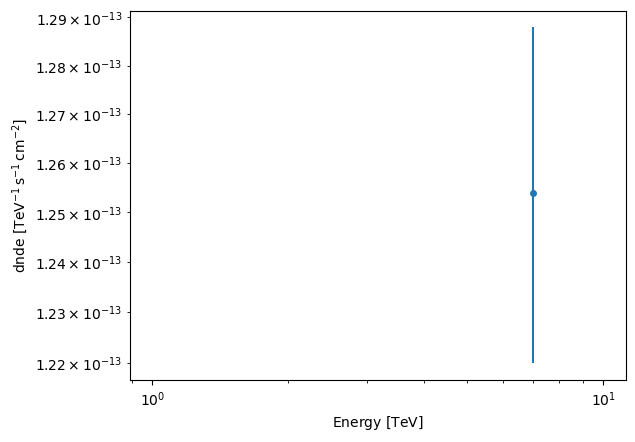

In [10]:
# Load the 3HWC catalog
catalog_3hwc = SourceCatalog3HWC()

# Select a specific source by name
source_3hwc = catalog_3hwc["3HWC J1825-134"]

# Generate FluxPoints for the 3HWC source
flux_points_3hwc = get_flux_points_3hwc(source_3hwc)
print("Flux Points Metadata (3HWC):")
print(flux_points_3hwc.meta)

# Plot the spectral energy distribution (SED)
flux_points_3hwc.plot()


In [11]:
# Inspect the catalog metadata
print("3HWC Catalog Metadata:")
print(catalog_3hwc.table.meta)

# Generate a flux points table for the 3HWC source
flux_points_table_3hwc = create_flux_points_table_3hwc(source_3hwc)
print("Flux Points Table (3HWC):")
print(flux_points_table_3hwc)


3HWC Catalog Metadata:
OrderedDict([('catalog_name', '3HWC'), ('reference', 'https://ui.adsabs.harvard.edu/abs/2020arXiv200708582A/abstract')])
Flux Points Table (3HWC):
e_ref       dnde         dnde_errn       dnde_errp        dnde_ul     is_ul
 TeV  1 / (TeV s cm2) 1 / (TeV s cm2) 1 / (TeV s cm2) 1 / (TeV s cm2)      
----- --------------- --------------- --------------- --------------- -----
    7        1.25e-13        3.41e-15        3.39e-15             nan False


## 2HWC Catalog Examples

This section demonstrates how to work with the 2HWC catalog:
1. Generate flux points and tables for a specific source using point and extended models.
2. Handle errors when the extended model is unavailable.
3. Plot the spectral energy distribution (SED).


In [12]:
# Load the 2HWC catalog
catalog_2hwc = SourceCatalog2HWC()

# Select a specific source by name
source_2hwc = catalog_2hwc["2HWC J1825-134"]

# Generate a flux points table for the 2HWC source (default 'point' model)
table_point_2hwc = create_flux_points_table_2hwc(source_2hwc)
print("Flux Points Table (2HWC, Point Model):")
print(table_point_2hwc)

# Generate a flux points table using the 'extended' model (if available)
try:
    table_extended_2hwc = create_flux_points_table_2hwc(source_2hwc, which="extended")
    print("Flux Points Table (2HWC, Extended Model):")
    print(table_extended_2hwc)
except ValueError as error:
    print(f"Extended Model Error (2HWC): {error}")


Flux Points Table (2HWC, Point Model):
e_ref       dnde          dnde_err    dnde_ul is_ul
 TeV  1 / (TeV s cm2) 1 / (TeV s cm2)              
----- --------------- --------------- ------- -----
7.000       1.380e-13       8.100e-15     nan False
Flux Points Table (2HWC, Extended Model):
e_ref       dnde          dnde_err    dnde_ul is_ul
 TeV  1 / (TeV s cm2) 1 / (TeV s cm2)              
----- --------------- --------------- ------- -----
7.000       2.490e-13       1.140e-14     nan False


In [13]:
# Generate a FluxPoints object for the 2HWC source using the point model
flux_points_point_2hwc = get_flux_points_2hwc(source_2hwc)
print("FluxPoints Object (2HWC, Point Model):")
print(flux_points_point_2hwc)

# Generate a FluxPoints object using the extended model (if available)
try:
    flux_points_extended_2hwc = get_flux_points_2hwc(source_2hwc, which="extended")
    print("FluxPoints Object (2HWC, Extended Model):")
    print(flux_points_extended_2hwc)
except ValueError as error:
    print(f"Extended Model Error (2HWC): {error}")


FluxPoints Object (2HWC, Point Model):
FluxPoints
----------

  geom                   : RegionGeom
  axes                   : ['lon', 'lat', 'energy']
  shape                  : (1, 1, 1)
  quantities             : ['norm', 'norm_err', 'norm_ul', 'is_ul']
  ref. model             : pl
  n_sigma                : 1
  n_sigma_ul             : None
  sqrt_ts_threshold_ul   : 2
  sed type init          : dnde

FluxPoints Object (2HWC, Extended Model):
FluxPoints
----------

  geom                   : RegionGeom
  axes                   : ['lon', 'lat', 'energy']
  shape                  : (1, 1, 1)
  quantities             : ['norm', 'norm_err', 'norm_ul', 'is_ul']
  ref. model             : pl
  n_sigma                : 1
  n_sigma_ul             : None
  sqrt_ts_threshold_ul   : 2
  sed type init          : dnde

